# 02 — Training Run

Reproducible training of the best configuration (Experiment 9). Seeds are pinned.

In [1]:
import sys, os
sys.path.append('..')

import random
import numpy as np
import torch
import yaml

# Pin seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

with open('../configs/default.yaml') as f:
    cfg = yaml.safe_load(f)

print('Config loaded:', cfg)

Config loaded: {'model': {'checkpoint': 'distilbert-base-uncased-finetuned-sst-2-english', 'dropout': 0.3}, 'data': {'dataset': 'stanfordnlp/imdb', 'max_length': 512, 'val_split': 0.2, 'seed': 42}, 'training': {'batch_size': 16, 'epochs': 3, 'learning_rate': 2e-05}, 'paths': {'checkpoint': 'checkpoints/best.pt', 'training_log': 'results/training_log.txt', 'figures_dir': 'results/figures', 'metrics': 'results/metrics.json'}}


In [2]:
from src.data import load_dataloaders
train_dl, val_dl, test_dl = load_dataloaders(cfg)

c:\Users\mario\miniconda3\envs\dl2026\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Map: 100%|██████████| 25000/25000 [00:05<00:00, 4226.78 examples/s]

Train: 20000 | Val: 5000 | Test: 25000


In [3]:
from src.model import SentimentClassifier

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
model = SentimentClassifier(
    checkpoint=cfg['model']['checkpoint'],
    dropout=cfg['model']['dropout'],
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total_params:,}')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3095.72it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased-finetuned-sst-2-english
Key                   | Status     |  | 
----------------------+------------+--+-
classifier.weight     | UNEXPECTED |  | 
classifier.bias       | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 
pre_classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Parameters: 66,364,418


In [4]:
import torch.nn as nn

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg['training']['learning_rate'])
loss_fn = nn.CrossEntropyLoss()
epochs = cfg['training']['epochs']

def evaluate(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for batch in loader:
            ids = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            labels = batch['label'].to(DEVICE)
            preds = model(ids, mask).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

losses, val_accs = [], []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch in train_dl:
        ids = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        labels = batch['label'].to(DEVICE)
        logits = model(ids, mask)
        loss = loss_fn(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        losses.append(loss.item())
    val_acc = evaluate(model, val_dl)
    val_accs.append(val_acc)
    print(f'Epoch {epoch+1}/{epochs} | loss: {epoch_loss/len(train_dl):.4f} | val acc: {val_acc:.4f}')

Epoch 1/3 | loss: 0.2322 | val acc: 0.9186
Epoch 2/3 | loss: 0.1329 | val acc: 0.9106
Epoch 3/3 | loss: 0.0618 | val acc: 0.9244


In [5]:
test_acc = evaluate(model, test_dl)
print(f'Test accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
assert test_acc > 0.92, 'Expected >= 92%'

os.makedirs('../checkpoints', exist_ok=True)
torch.save(model.state_dict(), '../checkpoints/best.pt')
print('Checkpoint saved.')

Test accuracy: 0.9289 (92.89%)
Checkpoint saved.


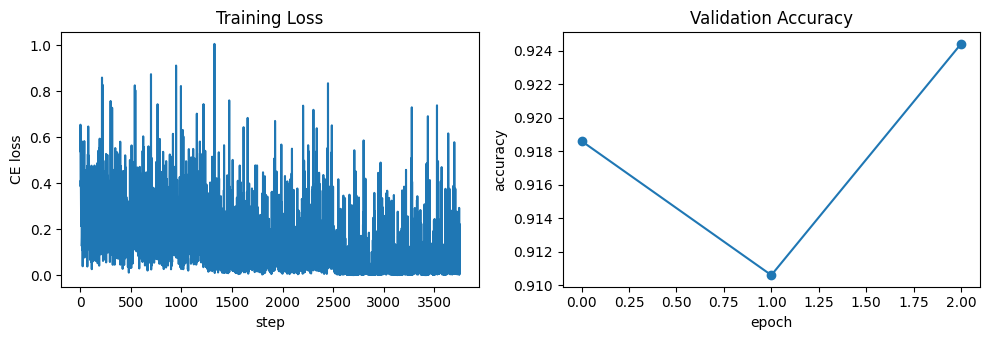

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.plot(losses)
ax1.set_title('Training Loss'); ax1.set_xlabel('step'); ax1.set_ylabel('CE loss')
ax2.plot(val_accs, marker='o')
ax2.set_title('Validation Accuracy'); ax2.set_xlabel('epoch'); ax2.set_ylabel('accuracy')
plt.tight_layout()
plt.savefig('../results/figures/training_curves.png', dpi=120)
plt.show()